# [LAB 07] 12-1. 교차분석의 이해
## #01. 준비작업
### 1. 라이브러리 참조

In [50]:
from hossam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame, crosstab

# 교차분석에 필요한 기능 참조
from scipy.stats import chisquare, chi2_contingency, fisher_exact

### 2. 데이터셋 불러오기

In [51]:
origin = load_data('movie_view')
origin.head()

📚 OTT 서비스 업체 무비뷰의 회원 500명을 대상으로 조사된 가상의 데이터 셋

    field         description
--  ------------  --------------------------------------
 0  회원ID        회원 식별자 (인덱스)
 1  가입요일      가입한 요일(월~일)
 2  성별          남성 / 여성
 3  프리미엄전환  프리미엄 요금제 전환 여부(전환/미전환)
 4  지역          서울 / 부산 / 대구
 5  선호장르      액션 / 로맨스 / 다큐 / 예능
 6  베타그룹      신규 UI 베타테스트 그룹(A/B)
 7  베타만족      베타테스트 만족 여부(만족/불만족)



,가입요일,성별,지역,선호장르,프리미엄전환,베타그룹,베타만족
회원ID,,,,,,,
M0001,토,여성,부산,다큐,미전환,NaN,NaN
M0002,토,남성,서울,예능,미전환,NaN,NaN
M0003,금,여성,대구,다큐,미전환,NaN,NaN
M0004,토,남성,서울,로맨스,미전환,NaN,NaN
M0005,일,남성,대구,다큐,미전환,NaN,NaN


### 3. 데이터 확인
- '베타그룹', '베타만족'만 비결측이 30건(베타 참여자)인 점에 주목한다

In [52]:
origin.info()

<class 'pandas.DataFrame'>
Index: 500 entries, M0001 to M0500
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   가입요일    500 non-null    str  
 1   성별      500 non-null    str  
 2   지역      500 non-null    str  
 3   선호장르    500 non-null    str  
 4   프리미엄전환  500 non-null    str  
 5   베타그룹    30 non-null     str  
 6   베타만족    30 non-null     str  
dtypes: str(7)
memory usage: 48.4 KB


## #02. 적합도 검정
### 1. 관측빈도와 기대 빈도 계산
- origin에서 가입요일의 요일별 관측빈도를 집계하고, 균등가정의 기대빈도를 함께 계산

In [53]:
# 요일 순서를 고정하기 위한 기준 리스트(월~일)
days = ['월', '화', '수', '목', '금', '토', '일']

# 요일별 가입자 수를 세고, days 순서대로 재정렬(관측빈도)
observed = origin['가입요일'].value_counts().reindex(days)

# 균등 가정 기대빈도 : 전체 인원을 7로 나눠 모든 요일에 동일하게 채움
expected = np.full(len(days), observed.sum() / len(days))

print('▶ 요일별 가입자 수 (관측빈도)')
print(observed)
print('\n▶ 균등 가정 기대빈도(요일당):', round(expected[0], 1))
print(expected.round(1))

▶ 요일별 가입자 수 (관측빈도)
가입요일
월     58
화     48
수     44
목     66
금     87
토     96
일    101
Name: count, dtype: int64

▶ 균등 가정 기대빈도(요일당): 71.4
[71.4 71.4 71.4 71.4 71.4 71.4 71.4]


### 2. 가정확인
- 적합도 검정도 기대빈도 >=5 가정을 따른다.
    - 5 이상 셀이 80% 이상이고, 1 미만 셀이 없어야함

In [54]:
n_under_5 = int((expected < 5).sum())  # 기대빈도가 5 미만인 칸의 개수
pct_ok = (expected >= 5).mean()        # 기대 빈도가 5 이상인 칸의 비율
min_exp = expected.min()               # 기대 빈도 중 최솟값 계산

print(f'전체 칸 수          : {expected.size}')
print(f'기대빈도 5미만 칸 수 : {n_under_5}')
print(f'기대빈도 5 이상 비율 : {pct_ok:.0%}')
print(f'최소 기대 빈도       : {min_exp:.1f}')

# 5 이상 비율 80% 이상 & 최소 기대빈도 1 이상이면 가정 충족
if pct_ok >= 0.8 and min_exp >=1:
    print('\n가정 충족 → 적합도 카이제곱 검정 사용 가능')
else:
    print('\n가정 위반 → 범주 병합 등 대안 검토')

전체 칸 수          : 7
기대빈도 5미만 칸 수 : 0
기대빈도 5 이상 비율 : 100%
최소 기대 빈도       : 71.4

가정 충족 → 적합도 카이제곱 검정 사용 가능


### 3. 적합도 검정수행
|구분|내용|
|-|-|
|귀무가설 H₀|요일별 가입 수가 모두 같다(균등분포).|
|대립가설 H₁|적어도 한 요일의 가입 수가 다르다.|

In [55]:
# 적합도 카이제곱 검정: 관측빈도와 기대빈도 비교 -> 통계량과 p-value 반환
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)
print('statistics:', chi2, 'p-value:', p)

statistics: 45.244 p-value: 4.185729660522544e-08


- p-value가 0.05보다 작아 균등 분포 가설을 기각한다.
- 즉, 요일에 따라 가입수에 통계적으로 유의한 차이가 있다.

### 4. 강도확인
- 유의성(p-value)과 별개로 차이의 크기를 본다.
- 적합도 검정의 효과크기는 cohen's w = $$w = \sqrt{\chi^2/n}$$이며, 0.1 약함/ 0.3 보통/ 0.5+ 강함으로 해석한다.​

In [56]:
n_total = observed.sum()  # 전체 표본 수(관측빈도 합계) 계산
cohen_w = np.sqrt(chi2 / n_total) # 효과크기 계산
print(f"Cohen's w : {cohen_w:.3f}")

Cohen's w : 0.301


- Cohen's w가 0.3안팎으로 보통 수준이다.
- 요일에 따른 가입 편차가 통계적으로 유의할 뿐 아니라 실질적 크기도 무시할 수준은 아니다.

### 5. 결과 시각화를 위한 데이터 재배치
- 관측빈도와 기대빈도를 long 형식으로 결합(hue로 나란히 비교하기 위함)

In [57]:
plot_df = DataFrame({
    # 요일 라벨을 관측/기대용으로 2번 반복
    '요일' : list(observed.index) * 2,
    # 앞쪽은 관측, 뒤쪽은 기대로 구분
    '구분': ['관측'] * len(days) + ['기대'] * len(days),
    # 관측빈도 + 기대빈도를 하나의 값 컬럼으로 결합
    '가입자수': list(observed.values) + list(expected)
})

plot_df

,요일,구분,가입자수
0,월,관측,58.000
1,화,관측,48.000
2,수,관측,44.000
3,목,관측,66.000
4,금,관측,87.000
5,토,관측,96.000
6,일,관측,101.000
7,월,기대,71.429
8,화,기대,71.429
9,수,기대,71.429


### 6. 결과 시각화

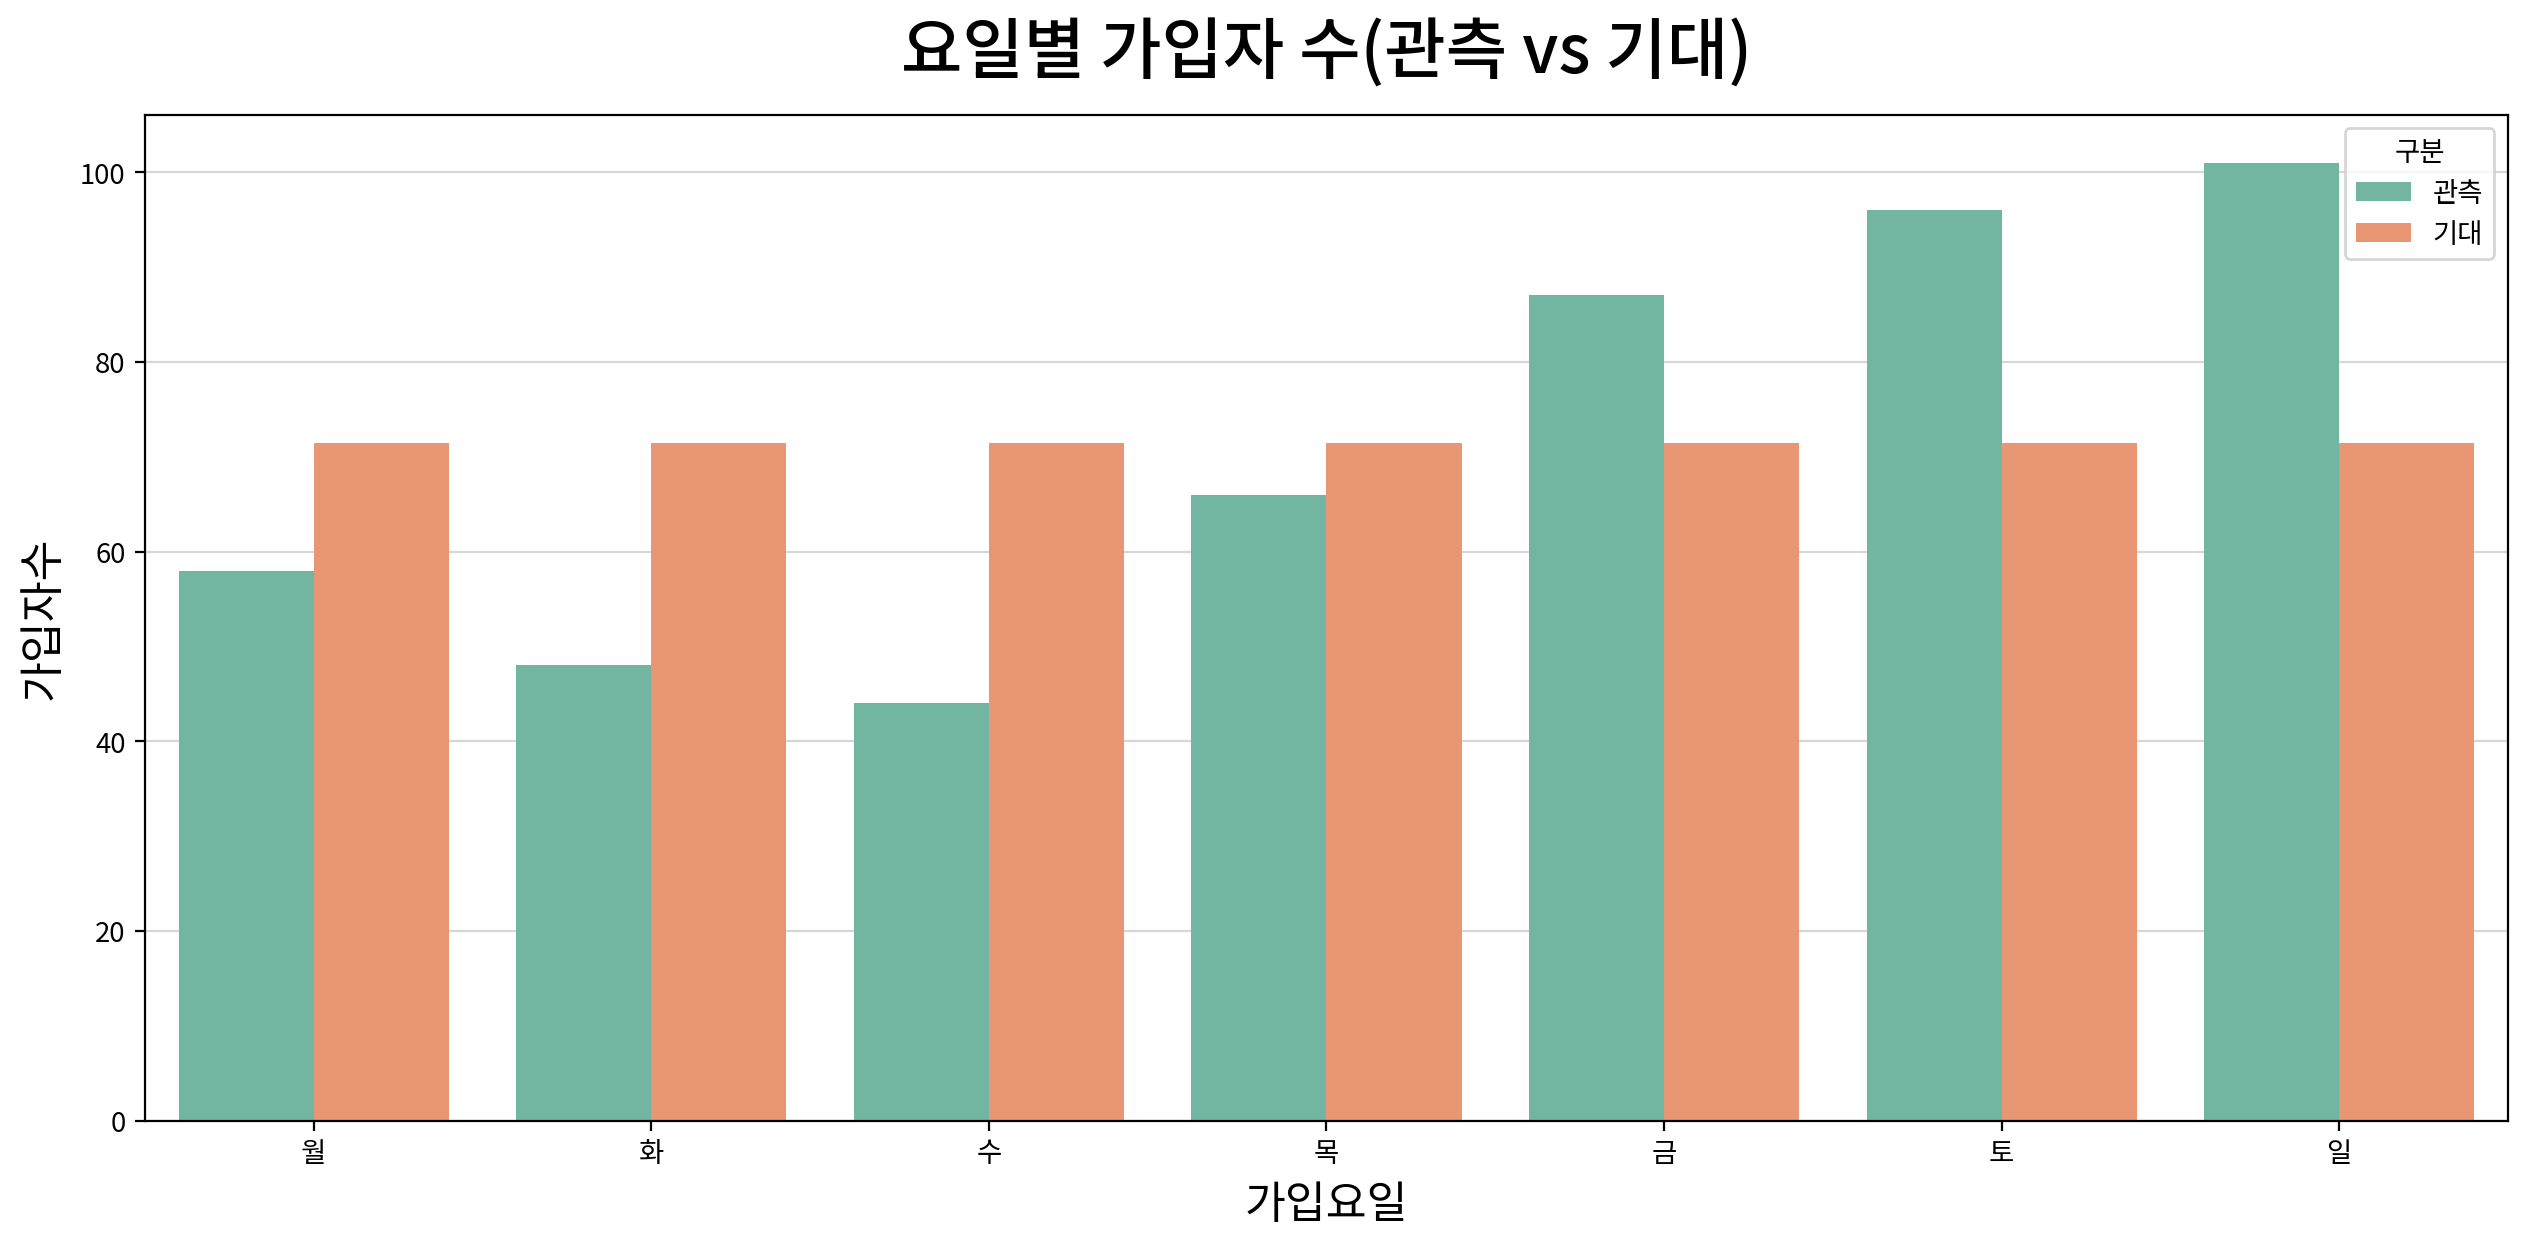

In [58]:
# 요일별 관측 vs 기대 빈도를 나란히 그리는 이중 막대 그래프
my_plot.barplot(data=plot_df, x='요일', y='가입자수', hue='구분', order=days, palette='Set2',
                title='요일별 가입자 수(관측 vs 기대)', xlabel='가입요일', ylabel='가입자수')

- 금, 토, 일에 가입이 뚜렷하게 몰린다.
- 주말 집중 현상이 통계적으로 확인되므로 주말 가입 프로모션 강화에는 근거가 있다.

## #03. 독립성 검정
### 1. 대상 데이터 전처리
- 한 집단을 두 범주형 변수로 분류했을 때 두 변수가 관련있는지 검정한다.
    - 여기서 성별과 프리미엄 전환의 관련성을 본다.
- 두 변수를 pandas의 crosstab 함수로 교차표(분할표)를 만든다.
    - 교차분석의 핵심 자료구조

In [59]:
ct = crosstab(origin['성별'], origin['프리미엄전환'])
ct['전환율'] = ct['전환'] / ct.sum(axis=1)
ct

프리미엄전환,미전환,전환,전환율
성별,,,
남성,169,73,0.302
여성,115,143,0.554


### 2. 가정확인
- chi2_contingency가 돌려주는 기대빈도로 가정(기대빈도>=5)을 점검한다.

In [60]:
data = ct[['미전환', '전환']].copy()
chi2, p, dof, expected = chi2_contingency(data)

# 기대빈도 확인
cdf = DataFrame(expected, index=data.index, columns=data.columns)
display(cdf)

pct_ok = (expected >=5).mean()
print(f'\n기대 빈도 5 미만 셀 수 : {int((expected < 5).sum())}')
print(f'최소 기대 빈도         : {expected.min():.1f}')
print('가정 충족 → 카이제곱 검정' if (pct_ok >= 0.8 and expected.min() >=1)
      else '가정 위반 → 대안 검토')

프리미엄전환,미전환,전환
성별,,
남성,137.456,104.544
여성,146.544,111.456



기대 빈도 5 미만 셀 수 : 0
최소 기대 빈도         : 104.5
가정 충족 → 카이제곱 검정


### 3. 독립성 검정 확인
|구분|내용|
|-|-|
|귀무가설 H₀|성별과 프리미엄 전환은 관계가 없다.|
|대립가설 H₁|성별에 따라 프리미엄 전환이 다르다.|

In [61]:
chi2, p, dof, expected = chi2_contingency(data)
print(f'\n카이제곱 통계량: {chi2:.3f}, p-value: {p:.3f}, 자유도: {dof}')


카이제곱 통계량: 31.453, p-value: 0.000, 자유도: 1


- p-value가 0.05보다 작아 귀무가설을 기각한다.
- 성별과 프리미엄 전환은 통계적으로 유의한 관계가 있다(여성 전환율이 더 높다).

### 4. 강도 확인
- 관계의 세기는 크라메르v $$V = \sqrt{\chi^2 / (n \cdot (\min(r,c)-1))}$$로 본다.
- 0.1 약함 / 0.3 보통 / 0.5% 강함

In [62]:
n_total = data.values.sum()
min_dim = min(data.shape)-1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f'크라메르 V : {cramers_v:.3f}')

크라메르 V : 0.251


- 크라메르 V가 약 0.25로 약함~보통 수준이다.
- 관계는 분명하지만 성별만으로 전환을 설명하기엔 부족하므로 보조 기준으로 활용한다.

### 5. 시각화

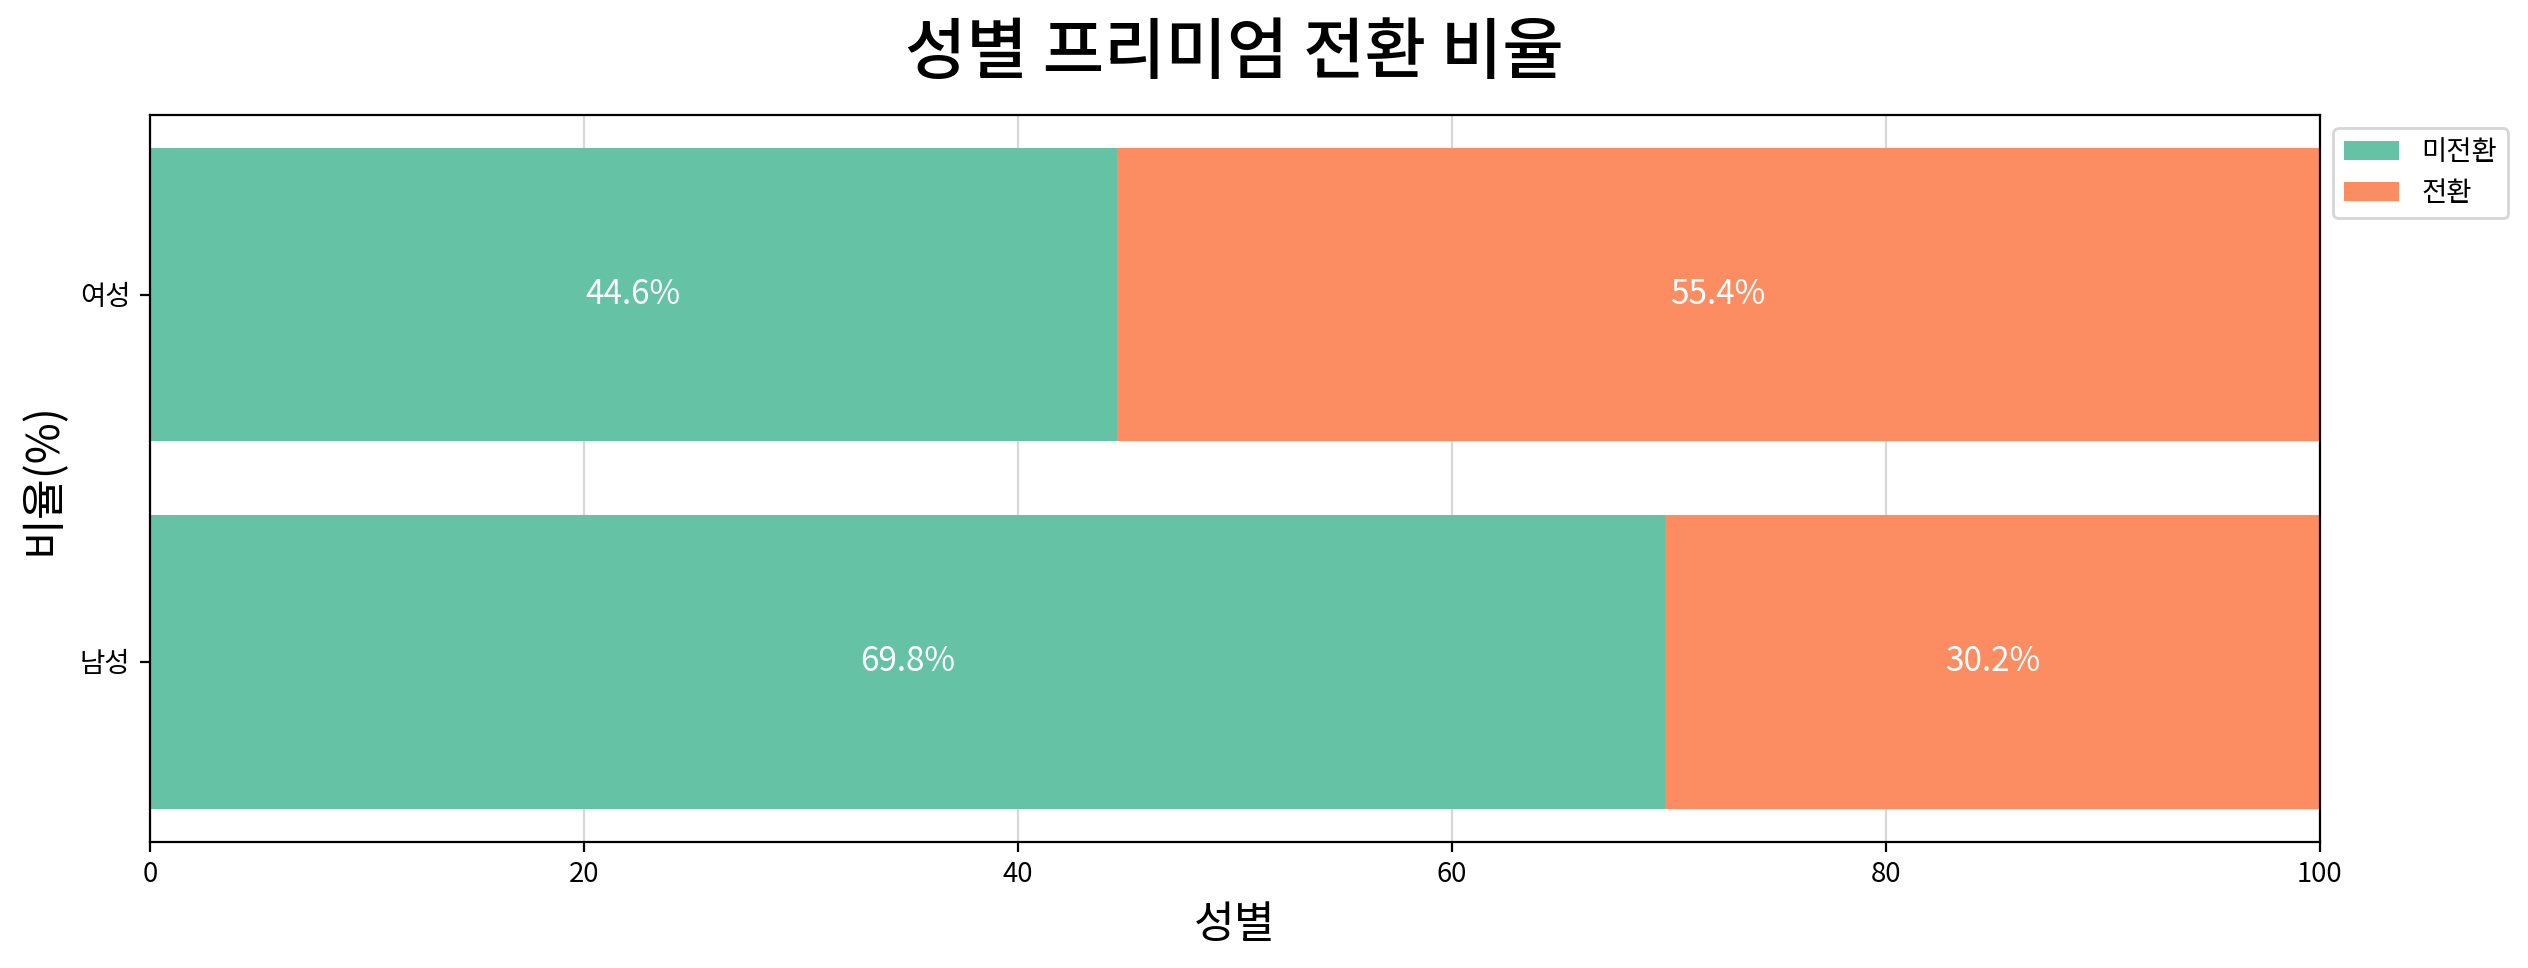

In [63]:
data = origin.copy()
data['인원'] = 1

my_plot.stackplot(data=data, x='성별', y='인원', hue='프리미엄전환', orient='h', aggfunc='sum', ratio=True,
                  palette='Set2', title='성별 프리미엄 전환 비율', xlabel='성별', ylabel='비율(%)', height=500)

- 남성과 여성의 프리미엄 전환 비율 차이가 어느 정도 참고할 수준으로 유의미한 차이를 보인다.

## #04. 동질성 검정
### 1. 대상 데이터 전처리
- 여러 집단에서 각각 표본을 모아 범주 분포가 같은지 비교
    - 계산은 독립성 검정과 동일
    - 여기서는 지역별로 선호장르 분포가 같은지 검정하기 위해 지역, 선호장르 교차표를 만든다.

In [64]:
ct2 = crosstab(origin['지역'], origin['선호장르'])
ct2

선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,49,21,18,42
부산,30,74,31,35
서울,29,34,83,54


### 2. 가정확인

In [65]:
chi2, p, dof, expected = chi2_contingency(ct2)

# 기대빈도 확인
cdf = DataFrame(expected, index=ct2.index, columns=ct2.columns)
display(cdf)

pct_ok = (expected >=5).mean()
print(f'\n기대 빈도 5 미만 셀 수 : {int((expected < 5).sum())}')
print(f'최소 기대 빈도         : {expected.min():.1f}')
print('가정 충족 → 카이제곱 검정' if (pct_ok >= 0.8 and expected.min() >=1)
      else '가정 위반 → 대안 검토')

선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,28.080,33.540,34.320,34.060
부산,36.720,43.860,44.880,44.540
서울,43.200,51.600,52.800,52.400



기대 빈도 5 미만 셀 수 : 0
최소 기대 빈도         : 28.1
가정 충족 → 카이제곱 검정


### 3. 동질성 검정
|구분|내용|
|-|-|
|귀무가설 H₀|세 지역의 장르 선호 분포는 동일하다.|
|대립가설 H₁|적어도 한 지역의 분포가 다르다.|

In [66]:
chi2, p, dof, expected = chi2_contingency(ct2)
print(f'\n카이제곱 통계량: {chi2:.3f}, p-value: {p:.3f}, 자유도: {dof}')


카이제곱 통계량: 86.156, p-value: 0.000, 자유도: 6


- p-value가 0.05보다 작아 분포가 동일하다는 가설을 기각한다.
- 지역에 따라 선호장르 분포가 통계적으로 유의하게 다르다.

### 4. 강도확인
- 동질성 검정의 효과크기도 크라메르V로 본다.
- 또한 표준화 잔차(절댓갑>=2면 주목)로 어느 칸이 차이를 만드는지 함께 확인한다.

In [67]:
n_total = ct2.values.sum()
min_dim = min(ct2.shape)-1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f'크라메르 V : {cramers_v:.3f}')

residuals = (ct2.values - expected) / np.sqrt(expected)
DataFrame(residuals.round(2), index=ct2.index, columns=ct2.columns)

크라메르 V : 0.294


선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,3.950,-2.170,-2.790,1.360
부산,-1.110,4.550,-2.070,-1.430
서울,-2.160,-2.450,4.160,0.220


- 크라메르v는 약함~보통 수준이지만 분포 차이는 분명하다ㅏ.
- 잔차를 보면 서울은 액션, 부산은 로맨스, 대구는 다큐선호가 기대보다 두드러진다 -> 지역별 콘텐츠 추천을 차별화할 근거가 된다.

### 5. 시각화

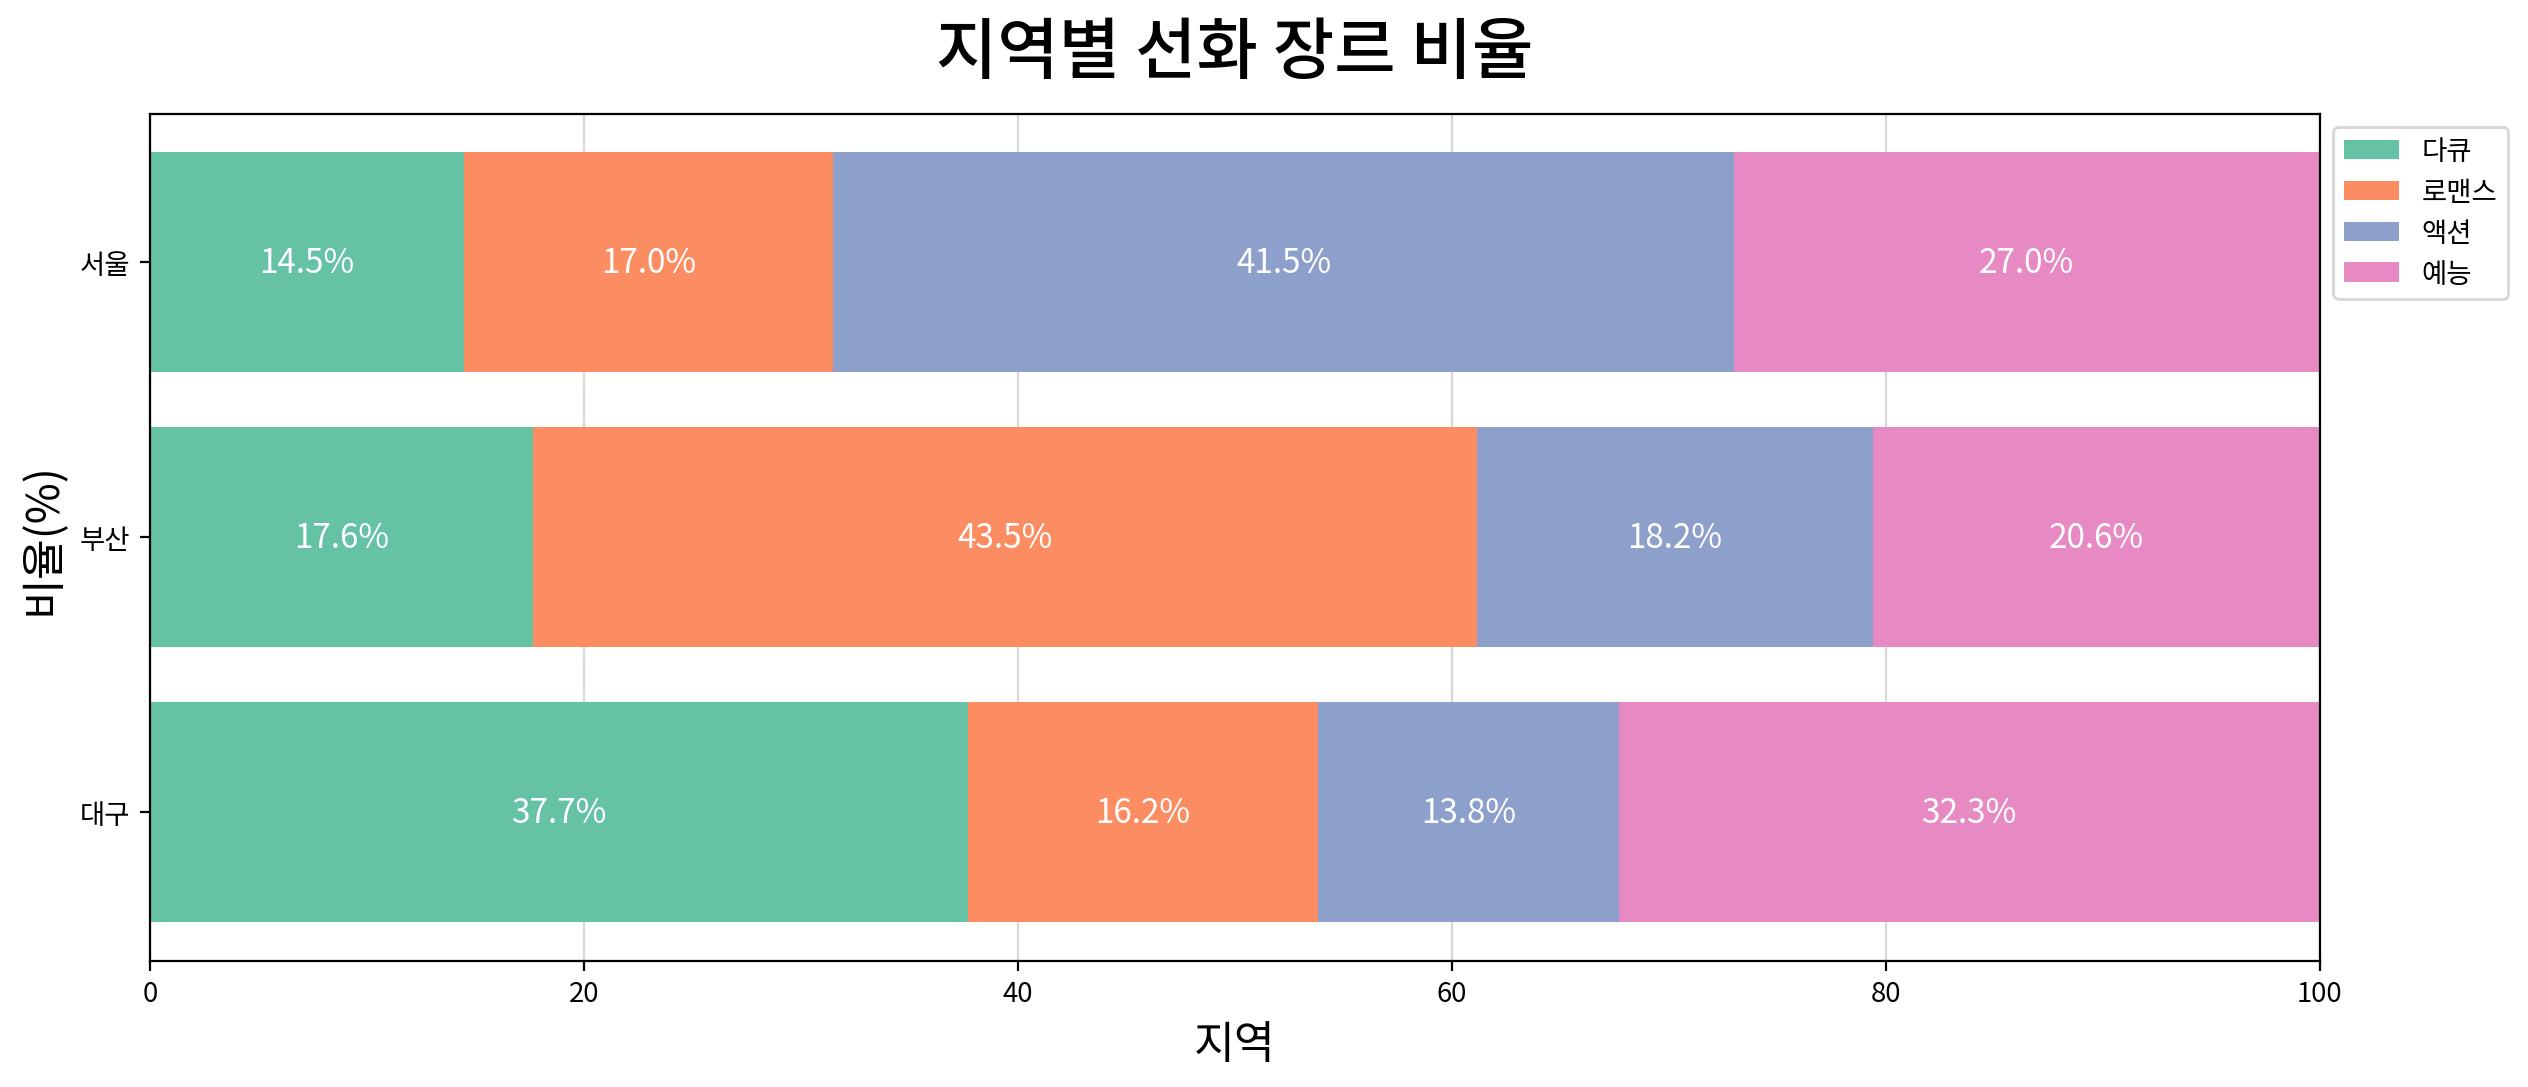

In [68]:
data = origin.copy()
data['인원'] = 1

my_plot.stackplot(data=data, x='지역', y='인원', hue='선호장르', orient='h', aggfunc='sum', ratio=True,
                  palette='Set2', title='지역별 선화 장르 비율', xlabel='지역', ylabel='비율(%)', height=560)

## #05. 가정에 위배된 경우(Fisher의 정확검정)
### 1. 대상 데이터 전처리
- 신규 UI를 시범 적용한 베타테스터 30명의 그룹 X 만족을 분석(A:신규UI, B:기존UI)
- 표본이 작아 기대빈도>=5 가정이 깨지는 상황
- origin에서 베타테스트 참여자만 남기는 결측 제거 전처리로 시작함 

In [69]:
# 데이터 정리 : 베타테스트 참여자만 추출
beta_df = origin.dropna(subset=['베타그룹', '베타만족']).copy()
print('베타테스트 참여자 수:', len(beta_df))

# 교차표
ct3 = crosstab(beta_df['베타그룹'], beta_df['베타만족'])
ct3 = ct3[['만족', '불만족']].reindex(['A', 'B'])
ct3

베타테스트 참여자 수: 30


베타만족,만족,불만족
베타그룹,,
A,17,1
B,8,4


### 2. 가정 확인

In [70]:
chi2, p, dof, expected = chi2_contingency(ct3)

print('▶ 기대빈도')
display(DataFrame(expected, index=ct3.index, columns=ct3.columns))

n_under_5 = int((expected < 5).sum())
print(f'\n기대빈도 5 미만 셀 수 : {n_under_5} / {expected.size}')
print(f'최소 기대빈도 : {expected.min():.1f}')

if (expected >= 5).mean() >= 0.8 and expected.min() >= 1:
    print('\n가정 충족')
else:
    print('\n가정 위반')

▶ 기대빈도


베타만족,만족,불만족
베타그룹,,
A,15.000,3.000
B,10.000,2.000



기대빈도 5 미만 셀 수 : 2 / 4
최소 기대빈도 : 2.0

가정 위반


### 3. 카이제곱 vs Fisher 검정
- 가정을 무시하고 카이제곱을 쓰면 결론이 어떻게 달라지는지 직접 비교한다.

In [71]:
# 예이츠 보정이 적용되지 않은 카이제곱 검정(카이제곱 검정의 원래 형태)
_, p_raw, _, _ = chi2_contingency(ct3, correction=False)
print(f'카이제곱(예이츠 보정 X) p-value : {p_raw:.4f}')

# 예이츠 보정이 적용된 카이제곱 검정(scipy의 기본값)
_, p_yates, _, _ = chi2_contingency(ct3)
print(f'카이제곱(예이츠 보정 O) p-value : {p_yates:.4f}')

# Fisher 정확검정
odds, p_fisher = fisher_exact(ct3)
print(f'Fisher 정확검정 p-value : {p_fisher:.4f}')

카이제곱(예이츠 보정 X) p-value : 0.0455
카이제곱(예이츠 보정 O) p-value : 0.1336
Fisher 정확검정 p-value : 0.1282


### 4. 시각화

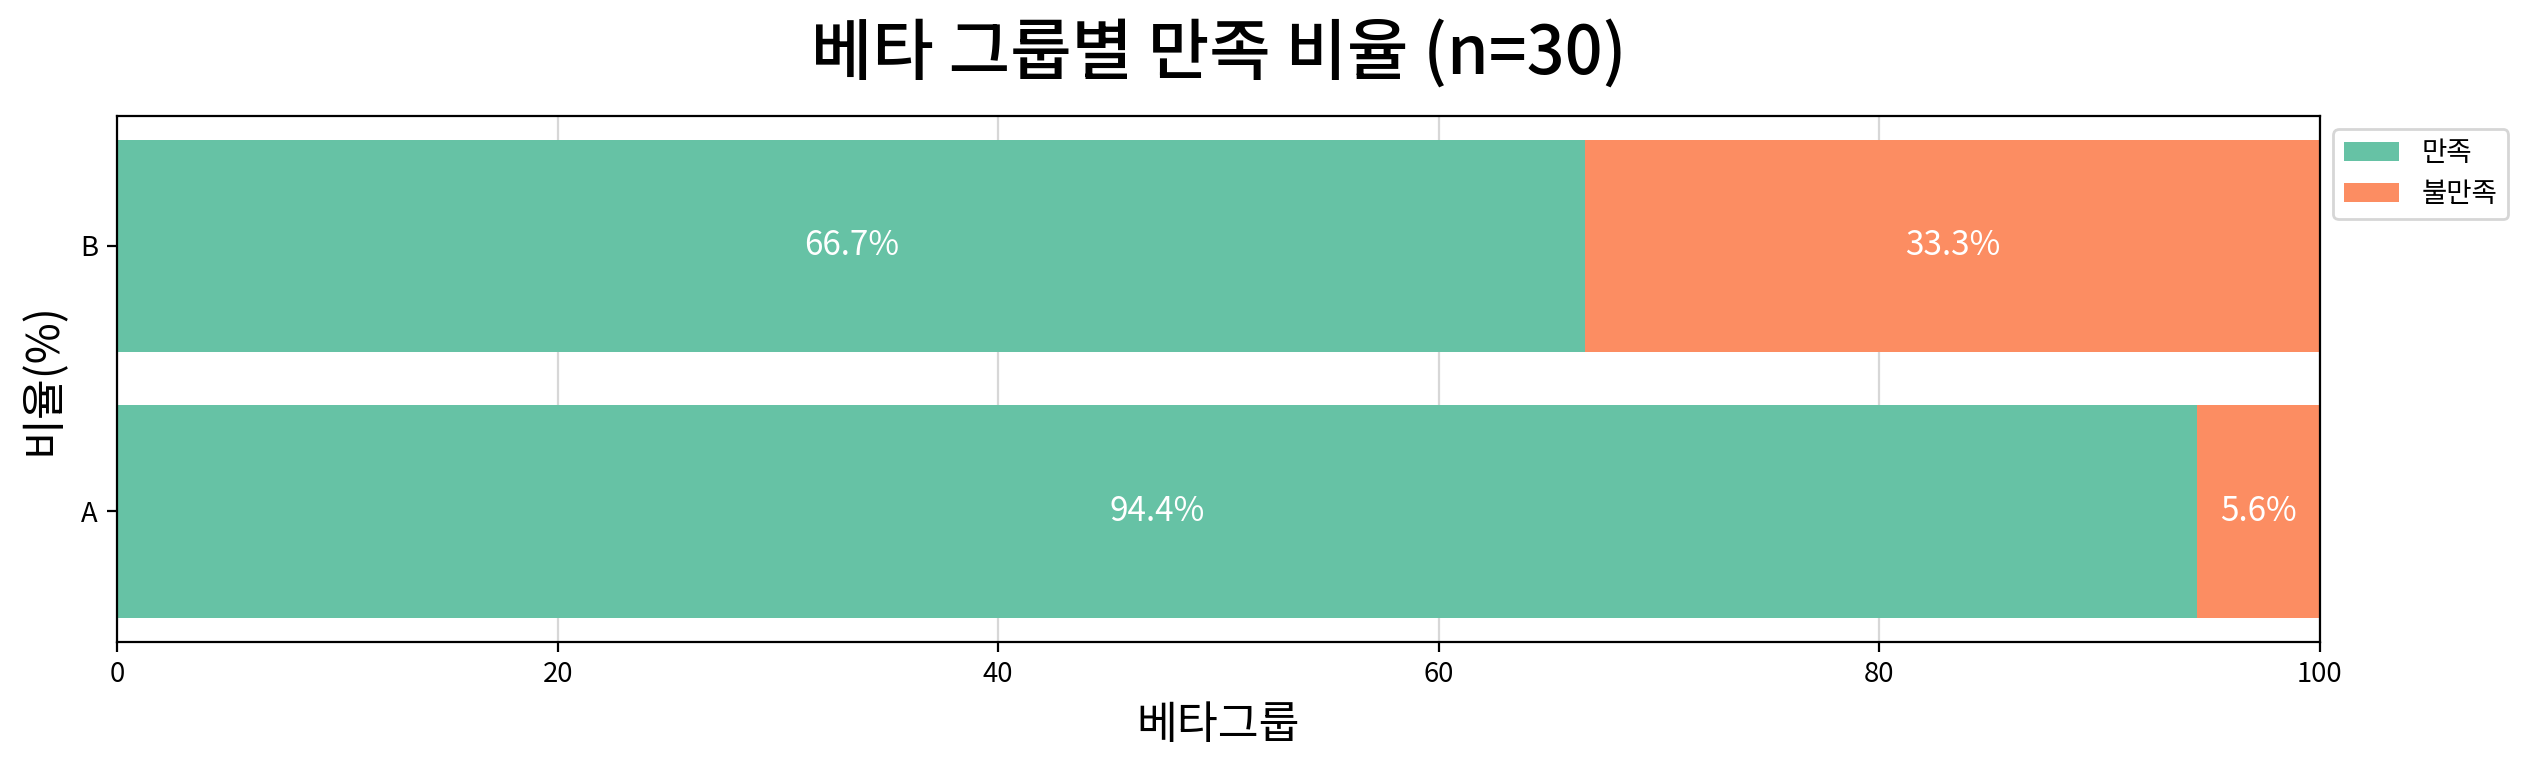

In [72]:
data = beta_df.copy()
data['인원'] = 1

my_plot.stackplot(data=data, x='베타그룹', y='인원', hue='베타만족', orient='h', aggfunc='sum',
    ratio=True, palette='Set2', title='베타 그룹별 만족 비율 (n=30)', xlabel='베타그룹', ylabel='비율(%)', height=400)